<a href="https://colab.research.google.com/github/sascott9655/ADS-504-Mushroom-Classification-Project/blob/main/Final_Project_Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mushroom Classification Project
###Samuel Scott, Julia Gonzalez, Bereket Tarekegn

**Project Goal:** Using machine learning techniques be able to properly determine if a mushrooms is poisonous or edible. This could be applied by reducing risk for cooks who use mushrooms to cook recipes, and collectors/foragers who rely on accurate identification of mushrooms. Based on observable features such as cap shape, gill structure, habitat, etc. to determine whether a mushroom is classified as edible or poisonous. This problem is important to solve as mushrooms if poisonous and consumed by humans can cause serious health effects such as organ failure or even death. Since the visual of mushrooms can be quite similar between poisonous and edible mushrooms, having a distinct classifier to detect mushroom edibility would provide safer decision making for cooks, foragers, and people that consume mushrooms.  

*Note: There is a text file called secondary_data_meta.txt that discusses what the unique values of some of the predictors mean.*

In [1]:
!git clone https://github.com/sascott9655/ADS-504-Mushroom-Classification-Project

fatal: destination path 'ADS-504-Mushroom-Classification-Project' already exists and is not an empty directory.


###Imports:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

#Section 1: Read in the Data

In [3]:
df = pd.read_csv('ADS-504-Mushroom-Classification-Project/secondary_data.csv', sep=';') #file separated by semicolon ;

In [4]:
df.shape

(61069, 21)

In [5]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [6]:
df.shape

(61069, 21)

In [7]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')

In [8]:
df.dtypes

,0
class,object
cap-diameter,float64
cap-shape,object
cap-surface,object
cap-color,object
does-bruise-or-bleed,object
gill-attachment,object
gill-spacing,object
gill-color,object
stem-height,float64


In [9]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [10]:
df.duplicated().sum()

np.int64(146)

In [11]:
df_clean = df.copy()

In [12]:
df_clean = df_clean.drop_duplicates()

In [13]:
missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percent": (df_clean.isnull().mean()*100).round(2)
})

missing.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
veil-type,57746,94.79
spore-print-color,54597,89.62
veil-color,53510,87.83
stem-root,51536,84.59
stem-surface,38122,62.57
gill-spacing,25062,41.14
cap-surface,14120,23.18
gill-attachment,9855,16.18
ring-type,2471,4.06
cap-color,0,0.00


In [14]:
#See which unique values show up most for each feature (sometimes it is the missing value NaN)
for col in df_clean.columns:
     print(df_clean[col].value_counts(dropna=False).head(10))

class
p    33742
e    27181
Name: count, dtype: int64
cap-diameter
3.18    99
3.14    97
3.85    94
3.25    93
3.24    93
4.04    93
3.33    92
3.13    91
3.45    91
2.87    91
Name: count, dtype: int64
cap-shape
x    26932
f    13404
s     7164
b     5694
o     3316
p     2598
c     1815
Name: count, dtype: int64
cap-surface
NaN    14120
t       8184
s       7580
y       6341
h       4974
g       4722
d       4432
e       2584
k       2303
i       2225
Name: count, dtype: int64
cap-color
n    24205
y     8541
w     7649
g     4312
e     4035
o     3653
r     1779
u     1709
p     1703
k     1279
Name: count, dtype: int64
does-bruise-or-bleed
f    50333
t    10590
Name: count, dtype: int64
gill-attachment
a      12697
d      10247
NaN     9855
x       7413
p       6001
e       5648
s       5648
f       3414
Name: count, dtype: int64
gill-spacing
NaN    25062
c      24682
d       7765
f       3414
Name: count, dtype: int64
gill-color
w    18492
n     9645
y     9545
p     5983
g     411

In [15]:
columns_to_fill = [
    "gill-spacing",
    "cap-surface",
    "gill-attachment",
    "ring-type"
]

for col in columns_to_fill:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [16]:
#we need to discover predictive power over these to ensure they are worth dropping
#(for now they will be dropped)

columns_to_drop = [
    "veil-type",
    "veil-color",
    "spore-print-color",
    "stem-root",
    "stem-surface"
]

df_clean = df_clean.drop(columns=columns_to_drop)

In [17]:
df_clean.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


In [18]:
df_clean["class"].value_counts()

,count
class,
p,33742
e,27181


In [19]:
df_clean["class"].value_counts(normalize=True) * 100

,proportion
class,
p,55.384666
e,44.615334


In [20]:
df_clean.to_csv(
    "/content/cleaned_secondary_mushroom.csv",
    index=False
)

In [21]:
df_clean[["cap-diameter", "stem-height", "stem-width"]].describe()

,cap-diameter,stem-height,stem-width
count,60923.000000,60923.000000,60923.000000
mean,6.741957,6.597202,12.178484
std,5.268435,3.358757,10.030361
min,0.380000,0.000000,0.000000
25%,3.490000,4.650000,5.250000
50%,5.880000,5.960000,10.220000
75%,8.550000,7.750000,16.580000
max,62.340000,33.920000,103.910000


In [22]:
df_clean["class"].unique()

array(['p', 'e'], dtype=object)

In [25]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(sorted(df_clean[col].unique()))



class:
['e', 'p']

cap-shape:
['b', 'c', 'f', 'o', 'p', 's', 'x']

cap-surface:
['Unknown', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y']

cap-color:
['b', 'e', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

does-bruise-or-bleed:
['f', 't']

gill-attachment:
['Unknown', 'a', 'd', 'e', 'f', 'p', 's', 'x']

gill-spacing:
['Unknown', 'c', 'd', 'f']

gill-color:
['b', 'e', 'f', 'g', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

stem-color:
['b', 'e', 'f', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

has-ring:
['f', 't']

ring-type:
['Unknown', 'e', 'f', 'g', 'l', 'm', 'p', 'r', 'z']

habitat:
['d', 'g', 'h', 'l', 'm', 'p', 'u', 'w']

season:
['a', 's', 'u', 'w']


##SAM

I want to change the names of all the unique values because the lettering makes it unclear what each
classification is, especially to non-mushroom experts

Changing unique value names because one letter is very confusing especially for non-mushroom enthusiast!

In [26]:
df_clean['class'] =df_clean['class'].map({'e': 'Edible', 'p': 'Poisonous'})
df_clean['has-ring'] = df_clean['has-ring'].map({'f': 'False', 't': 'True'})
df_clean['ring-type'] = df_clean['ring-type'].map({'p': 'pendant', 'l': 'large', 'c:': 'cobwebby', 'e': 'evanescent', 'r': 'flaring', 'g': 'grooved', 's': 'sheathing', 'y': 'scaly', 'f': 'no ring', '?': 'unknown'})
df_clean['habitat'] = df_clean['habitat'].map({'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths', 'u': 'urban', 'w': 'waste', 'd': 'woods', 'h': 'heaths'})
df_clean['season'] = df_clean['season'].map({'s': 'spring', 'u': 'summer', 'a': 'autumn', 'w': 'winter'})

The first important aspect is to check for class imbalance. For classification problems, class imbalance is a huge problem that can lead to serious unwanted bias in the data set. If 99% of the mushrooms are edible, for example, then just having a classifier predict if each label is edible, would give a 99% accuracy. If the class imbalance is that severe then we would need to balance the class labels, either by (LAROSE book does a great job explaining this and I will reference it in our report).

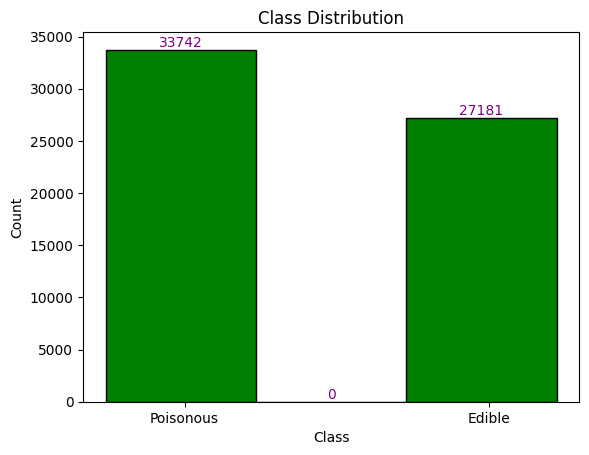

In [27]:
#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/
counts, bins, patches = plt.hist(df_clean['class'], bins=3, color='green', edgecolor='black')
plt.xticks([0.175, 0.85])
plt.bar_label(patches, color="purple")

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [28]:
df_clean['class'].value_counts(normalize=True).round(2)

,proportion
class,
Poisonous,0.55
Edible,0.45


The seaborn countplot determines the counts of each unique value for a particular feature. The important thing to note is that it is not the amount of mushrooms that matters for each unique value, but the distributions between each unique value, which is why crosstab is used below the visuals. If the difference is between the poisonous and edible classification is significant, then there might be significance for that unique value being a strong factor for determining mushroom edibility classification.

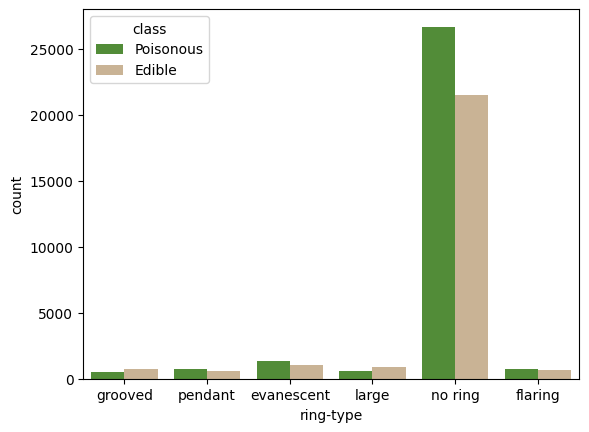

In [29]:
sns.countplot(x='ring-type', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [30]:
ring_type_dist = pd.crosstab(df_clean['ring-type'], df_clean['class'], normalize='index').round(2)
ring_type_dist

class,Edible,Poisonous
ring-type,,
evanescent,0.43,0.57
flaring,0.50,0.50
grooved,0.57,0.43
large,0.61,0.39
no ring,0.45,0.55
pendant,0.43,0.57


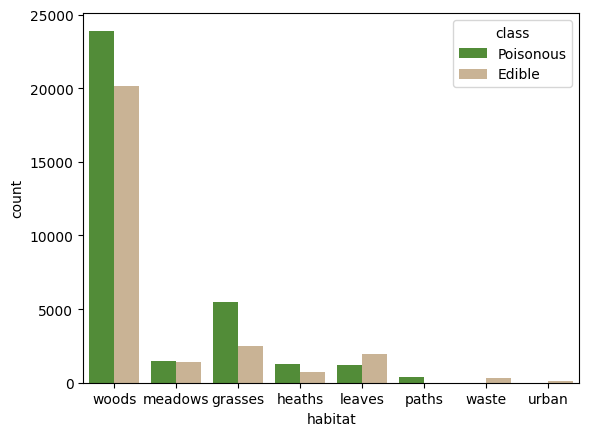

In [31]:
sns.countplot(x='habitat', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [32]:
#Numerical representation of the graph
habitat_dist = pd.crosstab(df_clean['habitat'], df_clean['class'], normalize='index').round(2)
habitat_dist

class,Edible,Poisonous
habitat,,
grasses,0.31,0.69
heaths,0.35,0.65
leaves,0.61,0.39
meadows,0.49,0.51
paths,0.00,1.00
urban,1.00,0.00
waste,1.00,0.00
woods,0.46,0.54


Mushrooms that live in paths, waste, and urban are determining factors that we can say it is one of the other immediately. Grasses and woods have significant differences so that could be a unique value for determining mushroom classification. Overall between habitat and ring-type, habitat seems like the stronger predictor for determining mushroom edibility

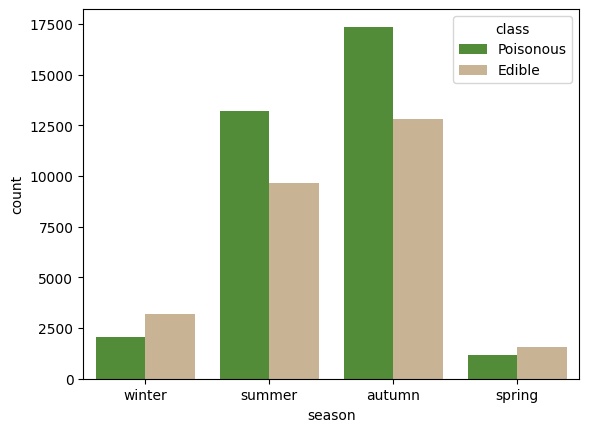

In [33]:
sns.countplot(x='season', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [34]:
season_dist = pd.crosstab(df_clean['season'], df_clean['class'], normalize='index').round(2)
season_dist

class,Edible,Poisonous
season,,
autumn,0.42,0.58
spring,0.58,0.42
summer,0.42,0.58
winter,0.61,0.39


The seasons predictor shows us that winter and spring mushrooms are more likely to be edible, while summer and autumn appear to have more poisonous mushrooms.

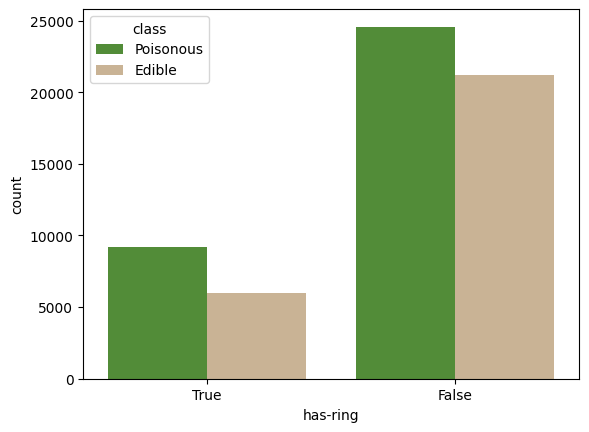

In [35]:
sns.countplot(x='has-ring', hue = 'class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [36]:
has_ring_dist = pd.crosstab(df_clean['has-ring'], df_clean['class'], normalize='index').round(2)
has_ring_dist

class,Edible,Poisonous
has-ring,,
False,0.46,0.54
True,0.40,0.60


This feature has-ring does not give a lot of information whether a mushroom is poisonous or not based on distributions. Habitat and seasons seem like the strongest predictors out of the four.

Train_test_split

In [41]:
misc_feats = df_clean[['ring-type', 'has-ring', 'habitat', 'season']]

In [42]:
X = misc_feats
y = df_clean["class"]

X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_one_hot, X_test_one_hot, y_train_one_hot, y_test_one_hot = train_test_split(X,y,test_size=0.2,random_state=42)

Encoding Features for Model
Using OrdinalEncoder for Tree Models since Tree models make decisions on features not on distance values.
Using OneHotEncoder for Logistic Regression and SVM since those models use distances to determine classification.

Ordinal Encoding for Tree Models:

In [43]:
ordinal_encoder = OrdinalEncoder()
X_train_ord_encoded = ordinal_encoder.fit_transform(X_train_ord)
X_test_ord_encoded = ordinal_encoder.transform(X_test_ord)

OneHotEncoding for Logistic Regression and SVM

When categorical attributes has hundreds or thousands of categories, one-hot encoding results in a very large matrix fulls of 0s except for a single 1 per row. A sparse matrix is needed because it will save memory and speed up compuatations - Geron book

In [44]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
X_train_one_hot_encoded = one_hot_encoder.fit_transform(X_train_one_hot)
X_test_one_hot_encoded = one_hot_encoder.transform(X_test_one_hot)

In [45]:
decision_tree_pipeline = Pipeline([
    ("encoder", ordinal_encoder),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [46]:
random_forest_pipeline = Pipeline([
    ("encoder", ordinal_encoder),
    ("model", RandomForestClassifier(random_state=42))
])

In [47]:
log_reg_pipleline = Pipeline([
    ("encoder", one_hot_encoder),
    ("model", LogisticRegression(random_state=42))
])

In [48]:
svm_pipeline = Pipeline([
    ("encoder", one_hot_encoder),
    ("model", SVC(random_state=42))
])

In [49]:
decision_tree_pipeline.fit(X_train_ord, y_train_ord)
d_tree_pred = decision_tree_pipeline.predict(X_test_ord)

In [50]:
random_forest_pipeline.fit(X_train_ord, y_train_ord)
rf_pred = random_forest_pipeline.predict(X_test_ord)

In [51]:
log_reg_pipleline.fit(X_train_one_hot, y_train_one_hot)
lr_pred = log_reg_pipleline.predict(X_test_one_hot)

In [52]:
svm_pipeline.fit(X_train_one_hot, y_train_one_hot)
svm_pred = svm_pipeline.predict(X_test_one_hot)

In [53]:
cross_val_score(decision_tree_pipeline, X_train_ord, y_train_ord, cv=5)

array([0.61274108, 0.61489536, 0.6056627 , 0.61793372, 0.61957525])

In [54]:
cross_val_score(random_forest_pipeline, X_train_ord, y_train_ord, cv=5)

array([0.61633156, 0.6187936 , 0.60874025, 0.62070381, 0.62265312])

In [55]:
cross_val_score(log_reg_pipleline, X_train_one_hot, y_train_one_hot, cv=5)

array([0.59509643, 0.59099302, 0.59355765, 0.59177183, 0.60233918])

In [56]:
cross_val_score(svm_pipeline, X_train_one_hot, y_train_one_hot, cv=5)

array([0.61633156, 0.61889618, 0.60894542, 0.62049861, 0.62532061])

In [57]:
cm_dtree = confusion_matrix(y_test_ord, d_tree_pred)
cm_dtree

array([[1408, 3957],
       [ 644, 6176]])

In [59]:
precision_score(y_test_ord, d_tree_pred, pos_label="Poisonous")

0.6094937333464917

In [61]:
recall_score(y_test_ord, d_tree_pred, pos_label="Poisonous")

0.9055718475073313

In [62]:
f1_score(y_test_ord, d_tree_pred, pos_label="Poisonous")

0.7286026072081637